# The Clausius-Clapeyron equation
|![Pollastrini - Inondazione del Serchio](images/pollastrini_flooding.png)|
|:--:|
|*Enrico Pollastrini - A family saved from flooding of the Serchio, 1845*|

The Clausius-Clapeyron equation represents the saturated vapor pressure as a function of the temperature. 
When a liquid is in equilibrium with its saturated vapor, its pressure depends only on the temperature. As the vapor pressure decreases part of the liquid evaporates. As the vapor pressure increases, part of it returns to the liquid phase. Considering a mass element that goes from one phase to another at temperature $T$ the change of specific volume is

$$dV = (v_2 - v_1)dm$$

and for the internal energy

$$dU = (u_2 - u_1)dm$$

from which we can write, using the expression of the first principle

$$\frac{dQ}{dm} = u_2 - u_1 + e_s(v_2 - v_1) = \lambda$$

where $e_s$ is the saturated vapor pressure and $\lambda$ is the *latent heat of vaporization* which depends on strenght of bonds between the molecules of a material and represents the amount of heat required to convert a mass of 1 g of liquid into a vapor state. From the ratio between the differentials of internal energy and volume, we obtain

$$\frac{dU}{dV} = \left ( \frac{\partial U}{\partial V} \right )_T = \frac{u_2 - u_1}{v_2 - v_1} = \frac{\lambda}{v_2 - v_1} - e_s$$

Since the entropy differential is an exact differential 

$$dS = \frac{dQ}{T}$$

from the expression of the first law of thermodynamics, dividing both sides by the temperature T

$$dS = \frac{dQ}{T} = \frac{1}{T}dU + \frac{e_s}{T}dV$$

and from the equality of mixed partial second derivatives for an exact differential

$$\frac{\partial^2 S}{\partial T \partial V} = \frac{\partial^2 S}{\partial V \partial T}$$

we get the equation 

$$\left( \frac{\partial U}{\partial V} \right)_T = T \left( \frac{\partial e_s}{\partial T} \right)_V - e_s$$

Comparing with the equation containing the latent heat of vaporization we get

$$\frac{de_s}{dT} = \frac{\lambda}{T(v_2 -v_1)}$$

which is the Clausius-Clapeyron equation. Considering that the specific volume of vapor is much larger than that of liquid, $v_2 >> v_1$ and vapor as an ideal gas we can use the equation of state of a perfect gas

$$e_sv_2 = \frac{R}{M}T$$

to substitute the volume into the Clapeyron equation and get

$$\frac{de_s}{e_s} = \frac{\lambda M}{RT^2} dT$$

from which, assuming the latent heat of vaporization to be constant and integrating, we obtain

$$e_s = e_0 e^{\frac{\lambda M}{R}(\frac{1}{T_0} - \frac{1}{T})}$$

We import the Python packages

In [5]:
import numpy as np
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt

In [81]:
def eq_clapeyron(T):
    '''
    This function calculates the water vapour pressure 
    from the temperature given in Kelvin using the 
    Clausius-Clapeyron equation. The return values are in kPa.
    '''
    R = 8.314  # J/(Kmol) gas constant
    M = 18.015 * 10 ** (-3) # Kg/mol vapour molar mass 
    p_0 = 0.6113 # kPa vapour pressure at T = 273.15
    T_0 = 273.15 # K
    L = 2.5 * 10 ** 6 # J/Kg latent heat of vaporization
    R_v = R / M 
    return p_0 * np.exp((L/R_v) * (1/T_0 - 1/T)) # kPa

In [62]:
round(eq_clapeyron(303.15), 3)

4.351

## Interpretation of the Clausius-Clapeyron equation
The exponential plot separates three regions: the supersaturated region above, the saturated region represented by the equation plot, and the unsatured region below. When a parcel of unsaturated humid air, that is air containing water molecules, is cooled while raising and reaches a certain temperature, the air in the parcel is saturated. Further cooling forces some water vapor to condense into droplets releasing latent heat that can be seen as clouds and, f the process proceeds, into rain drops and precipitation.

In [87]:
T_K = np.linspace(273.15, 323.15, 100) 
e_c = eq_clapeyron(T_K) # kPa

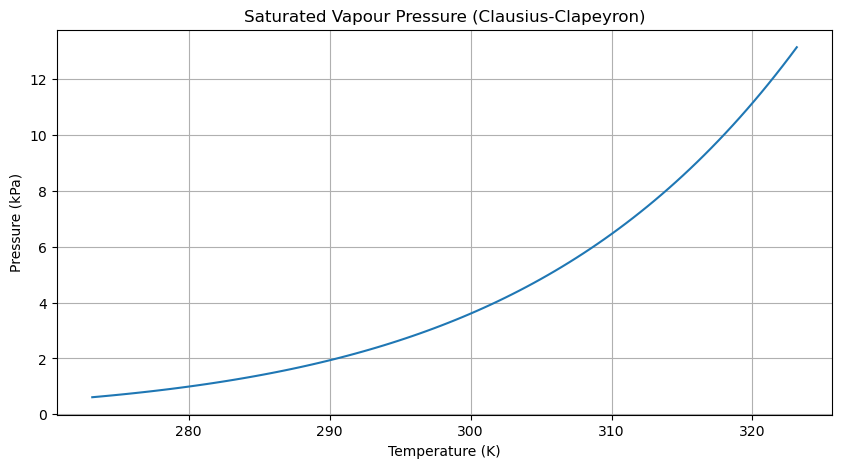

In [95]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot()
ax.grid(True)
ax.set_title("Saturated Vapour Pressure (Clausius-Clapeyron)")
ax.set_xlabel("Temperature (K)")
ax.set_ylabel("Pressure (kPa)");
ax.plot(T_K, e_c)
plt.savefig('clausius-clapeyron.png')

## August-Roche-Magnus approximation
The latent heat of vaporization $\lambda$ varies slightly with temperature and several approximations have been developed of the Clausius-Clapeyron equation to take this fact into account. One such approximation is called the August-Roche-Magnus approximation, valid under typical atmospheric conditions. It can be written as

$$ e_s(T) = c * exp(\frac{aT}{b + T}) $$

where a, b and c are constants and T is the temperature. It tells us how much the saturated vapor pressure in the atmosphere increases for each additional degree of temperature, and therefore how much more vapor the air can contain before it will condense onto an aerosol particle, turn into a droplet of water and eventually rain. The higher the temperature the heavier the expected rainfall. In numbers it is about 7% more vapor in the atmosphere for each additional degree Celsius. Of course there must be a source of humidity, such as the sea. Italy, being in the middle of the Mediterranean sea, is therefore in an optimal place to have alternating droughts and floods. The equation is simple, at least in the approximation valid for the atmosphere, but extremely important and it is worth spending 2 minutes to write the code and plot the function so that it will be easier to keep in mind.

In [96]:
a = 17.625
b = 243.04
c = 6.1094
T = np.linspace(0, 50, 100) # °C
e_a = c * np.exp(a * T / (b + T)) / 10 # kPa

We build the model (function) and compute the value of the saturated water pressure within an interval of temperatures, between 0 and 50 degree Celsius

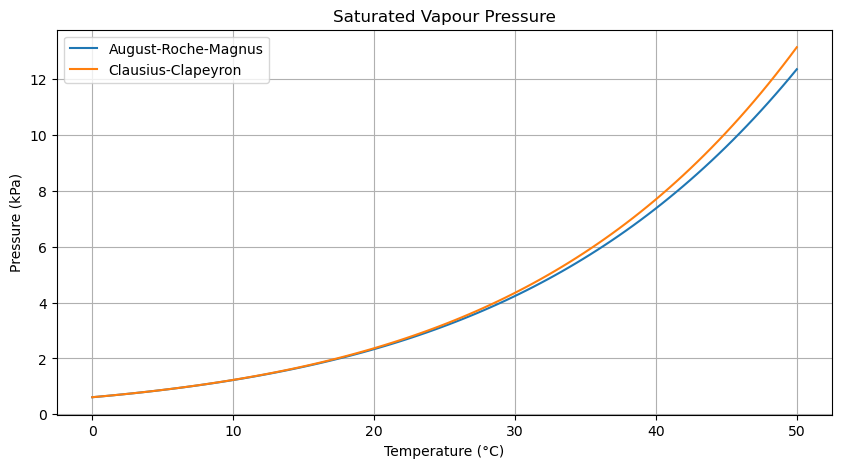

In [97]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot()
ax.grid(True)
ax.set_title('Saturated Vapour Pressure')
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Pressure (kPa)');
ax.plot(T, e_a, label='August-Roche-Magnus')
ax.plot(T, e_c, label='Clausius-Clapeyron')
ax.legend()
#plt.savefig('clausius-clapeyron.png')

## References
- Fermi - Termodinamica 
- [Wikipedia - Clausius-Clapeyron relation](https://en.wikipedia.org/wiki/Clausius%E2%80%93Clapeyron_relation)
- [Alduchov, Eskridge - Improved Magnus Form Approximation of Saturation Vapor Pressure](https://doi.org/10.1175/1520-0450(1996)035<0601:IMFAOS>2.0.CO;2)